In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance

RANDOM_STATE = 67
N_SPLITS = 5


In [2]:
X_train = pd.read_csv("artifical_train_data.csv")
y_train = pd.read_csv("artifical_train_labels.csv")["Class"]
X_test  = pd.read_csv("artifical_test_data.csv")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape, "klasy:", sorted(y_train.unique()))
print("X_test :", X_test.shape)

display(X_train.head())
display(y_train.value_counts().sort_index())


X_train: (1500, 100)
y_train: (1500,) klasy: [1, 2]
X_test : (500, 100)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100
0,500,441,400,445,519,447,479,484,549,424,...,436,477,496,458,454,526,563,448,518,454
1,535,454,513,437,502,471,506,490,371,441,...,519,484,500,460,493,497,489,462,489,500
2,473,469,527,487,478,461,454,438,419,532,...,537,492,467,480,449,474,481,464,463,523
3,490,480,518,453,487,468,454,473,533,536,...,518,487,485,457,460,465,445,468,511,470
4,443,472,504,511,481,487,497,469,416,559,...,511,472,483,502,481,514,513,483,474,530


Class
1    755
2    745
Name: count, dtype: int64

Braki danych (train): 0
Braki danych (test) : 0


,count,pct
Class,,
1,755,50.33
2,745,49.67


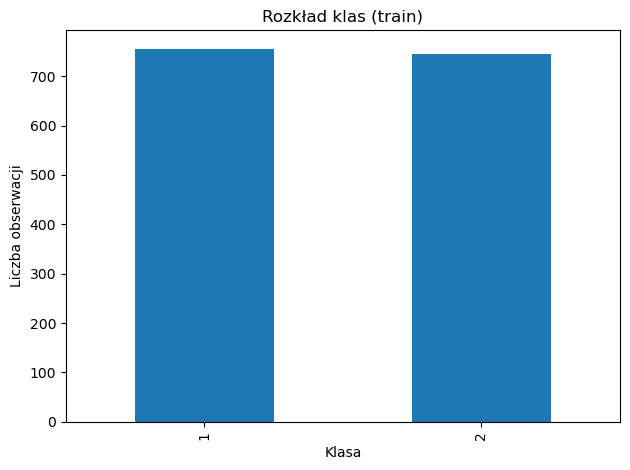

In [3]:
missing_train = int(X_train.isna().sum().sum())
missing_test  = int(X_test.isna().sum().sum())
print("Braki danych (train):", missing_train)
print("Braki danych (test) :", missing_test)

counts = y_train.value_counts().sort_index()
pct = (counts / len(y_train) * 100).round(2)
display(pd.DataFrame({"count": counts, "pct": pct}))

plt.figure()
counts.plot(kind="bar")
plt.title("Rozkład klas (train)")
plt.xlabel("Klasa")
plt.ylabel("Liczba obserwacji")
plt.tight_layout()
plt.show()


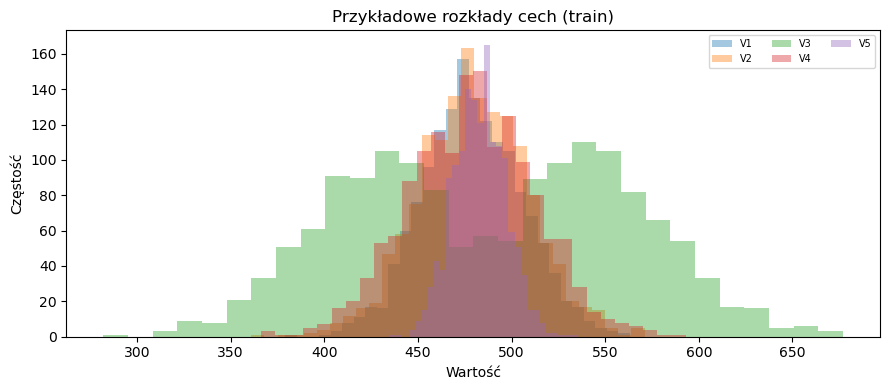

In [4]:
sample_cols = list(X_train.columns[:5])
plt.figure(figsize=(9,4))
for c in sample_cols:
    plt.hist(X_train[c], bins=30, alpha=0.4, label=c)
plt.title("Przykładowe rozkłady cech (train)")
plt.xlabel("Wartość")
plt.ylabel("Częstość")
plt.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()


In [5]:
corr = X_train.corr()
cols = X_train.columns
pairs = []
thr = 0.95

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        c = corr.iloc[i, j]
        if abs(c) >= thr:
            pairs.append((cols[i], cols[j], float(c)))

high_corr = pd.DataFrame(pairs, columns=["feat_a","feat_b","corr"]).sort_values("corr", ascending=False)
print("Liczba par z |corr|>=0.95:", len(high_corr))
display(high_corr.head(15))


Liczba par z |corr|>=0.95: 12


,feat_a,feat_b,corr
2,V9,V65,0.991098
8,V50,V73,0.989701
7,V43,V73,0.989635
10,V57,V90,0.989475
1,V8,V83,0.989457
9,V57,V87,0.989100
5,V42,V67,0.989044
11,V87,V90,0.988920
6,V43,V50,0.988787
3,V10,V58,0.988740


In [6]:
models = {
    "LogReg_elasticnet": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            l1_ratio=0.5,
            C=1.0,
            max_iter=20000,
            random_state=RANDOM_STATE
        ))
    ]),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "ExtraTrees": ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=1),
    "LinearSVM_calibrated": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", CalibratedClassifierCV(
            estimator=LinearSVC(random_state=RANDOM_STATE, max_iter=100000),
            method="sigmoid",
            cv=3
        ))
    ]),
}

param_grids = {
    "LogReg_elasticnet": {"clf__C": [0.1, 1.0], "clf__l1_ratio": [0.1, 0.5]},
    "HistGradientBoosting": {"learning_rate": [0.05, 0.1], "max_depth": [3, 5], "max_iter": [200], "min_samples_leaf": [20]},
    "ExtraTrees": {"n_estimators":[100,200,400], "min_samples_leaf":[1,2,5], "max_features":["sqrt", 0.5]},
    "LinearSVM_calibrated": {"clf__estimator__C": [0.3, 1.0]},
}


In [7]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

rows = []
for name, est in models.items():
    res = cross_validate(
        est, X_train, y_train,
        cv=cv,
        scoring={"bal_acc": "balanced_accuracy", "roc_auc": "roc_auc"},
        n_jobs=1
    )
    for i in range(N_SPLITS):
        rows.append({
            "model": name,
            "fold": i + 1,
            "balanced_accuracy": float(res["test_bal_acc"][i]),
            "roc_auc": float(res["test_roc_auc"][i]),
        })

cv_scores = pd.DataFrame(rows)
display(cv_scores)

summary = cv_scores.groupby("model").agg(
    bal_acc_mean=("balanced_accuracy", "mean"),
    bal_acc_std=("balanced_accuracy", "std"),
    roc_auc_mean=("roc_auc", "mean"),
    roc_auc_std=("roc_auc", "std"),
).reset_index().sort_values("bal_acc_mean", ascending=False)

for c in ["bal_acc_mean", "bal_acc_std", "roc_auc_mean", "roc_auc_std"]:
    summary[c] = summary[c].round(3)

display(summary)



,model,fold,balanced_accuracy,roc_auc
0,LogReg_elasticnet,1,0.573403,0.613672
1,LogReg_elasticnet,2,0.583381,0.628339
2,LogReg_elasticnet,3,0.533046,0.571181
3,LogReg_elasticnet,4,0.593137,0.607938
4,LogReg_elasticnet,5,0.589737,0.629228
5,HistGradientBoosting,1,0.836548,0.892529
6,HistGradientBoosting,2,0.763878,0.862572
7,HistGradientBoosting,3,0.746655,0.831904
8,HistGradientBoosting,4,0.796591,0.883506
9,HistGradientBoosting,5,0.796769,0.881106


,model,bal_acc_mean,bal_acc_std,roc_auc_mean,roc_auc_std
1,HistGradientBoosting,0.788,0.035,0.870,0.024
0,ExtraTrees,0.777,0.033,0.856,0.029
3,LogReg_elasticnet,0.575,0.024,0.610,0.024
2,LinearSVM_calibrated,0.570,0.016,0.608,0.023


In [8]:
best_rows = []
best_estimators = {}
best_params_map = {}

for name, est in models.items():
    gs = GridSearchCV(
        est,
        param_grids[name],
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=1,
        refit=True
    )
    gs.fit(X_train, y_train)

    best_rows.append({
        "model": name,
        "best_cv_bal_acc": float(gs.best_score_),
        "best_params": gs.best_params_
    })
    best_estimators[name] = gs.best_estimator_
    best_params_map[name] = gs.best_params_

best_df = pd.DataFrame(best_rows).sort_values("best_cv_bal_acc", ascending=False)
best_df["best_cv_bal_acc"] = best_df["best_cv_bal_acc"].round(3)
display(best_df)

best_model_name = best_df.iloc[0]["model"]
best_estimator = best_estimators[best_model_name]
best_params = best_params_map[best_model_name]

print("Wybrany model:", best_model_name)
print("Best params:", best_params)



,model,best_cv_bal_acc,best_params
2,ExtraTrees,0.857,"{'max_features': 0.5, 'min_samples_leaf': 2, '..."
1,HistGradientBoosting,0.773,"{'learning_rate': 0.05, 'max_depth': 5, 'max_i..."
0,LogReg_elasticnet,0.579,"{'clf__C': 0.1, 'clf__l1_ratio': 0.5}"
3,LinearSVM_calibrated,0.572,{'clf__estimator__C': 0.3}


Wybrany model: ExtraTrees
Best params: {'max_features': 0.5, 'min_samples_leaf': 2, 'n_estimators': 400}


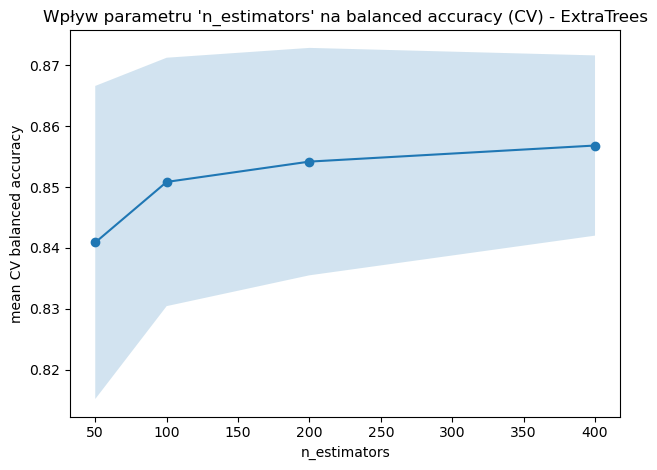

,n_estimators,mean_balanced_accuracy,std_balanced_accuracy
0,50,0.8409,0.0257
1,100,0.8508,0.0204
2,200,0.8542,0.0187
3,400,0.8568,0.0148


In [13]:
from sklearn.base import clone

if best_model_name == "ExtraTrees":
    param_name = "n_estimators"
    param_values = [50, 100, 200,400]
elif best_model_name == "HistGradientBoosting":
    param_name = "learning_rate"
    param_values = [0.03, 0.05, 0.1]
elif best_model_name == "LogReg_elasticnet":
    param_name = "clf__C"
    param_values = [0.1, 1.0, 3.0]
else:  # LinearSVM_calibrated
    param_name = "clf__estimator__C"
    param_values = [0.1, 0.3, 1.0]

means, stds = [], []
for v in param_values:
    est = clone(best_estimator)
    est.set_params(**{param_name: v})
    res = cross_validate(est, X_train, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=1)
    means.append(res["test_score"].mean())
    stds.append(res["test_score"].std())

means = np.array(means)
stds = np.array(stds)

plt.figure()
plt.plot(param_values, means, marker="o")
plt.fill_between(param_values, means - stds, means + stds, alpha=0.2)
plt.title(f"Wpływ parametru '{param_name}' na balanced accuracy (CV) - {best_model_name}")
plt.xlabel(param_name)
plt.ylabel("mean CV balanced accuracy")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    param_name: param_values,
    "mean_balanced_accuracy": np.round(means, 4),
    "std_balanced_accuracy": np.round(stds, 4),
}))


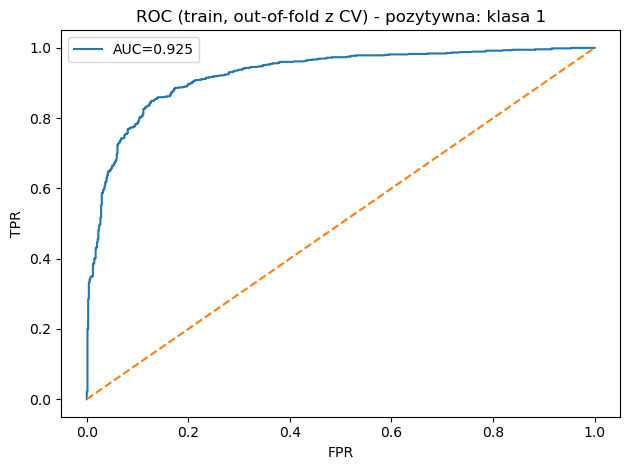

In [14]:
proba_oof = cross_val_predict(best_estimator, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1)
classes = best_estimator.classes_
idx1 = int(np.where(classes == 1)[0][0])
p1_oof = proba_oof[:, idx1]
y_bin = (y_train == 1).astype(int)

fpr, tpr, _ = roc_curve(y_bin, p1_oof)
auc = roc_auc_score(y_bin, p1_oof)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC (train, out-of-fold z CV) - pozytywna: klasa 1")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

best_estimator.fit(X_tr, y_tr)

perm = permutation_importance(
    best_estimator, X_val, y_val,
    scoring="balanced_accuracy",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=1
)

imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(imp.head(15))




,feature,importance_mean,importance_std
9,V10,0.035757,0.011813
57,V58,0.033095,0.011410
2,V3,0.020873,0.009120
89,V90,0.017991,0.009548
56,V57,0.017695,0.007905
86,V87,0.016675,0.008443
66,V67,0.012531,0.007853
50,V51,0.012414,0.009194
72,V73,0.012355,0.007643
41,V42,0.011248,0.007987


In [12]:
best_estimator.fit(X_train, y_train)

proba_test = best_estimator.predict_proba(X_test)
idx1 = int(np.where(best_estimator.classes_ == 1)[0][0])
p1_test = proba_test[:, idx1]

with open("333077_artifical_prediction.txt", "w", encoding="utf-8") as f:
    for v in p1_test:
        f.write(f"{float(v):.10f}\n")

